## Dataset Description — Rain in Australia (weatherAUS)

**Source:** Kaggle — "Rain in Australia" (jsphyg/weather-dataset-rattle-package),
original data from the Australian Bureau of Meteorology (BOM).

**Context:** ~10 years of daily weather observations collected from
multiple weather stations across Australia.

**Size:** 145,460 rows x 23 columns

**Target variable:** `RainTomorrow` (Yes/No) — indicates whether it rained the next day.


**Main columns:**
- `Date` — observation date
- `Location` — city / weather station
- `MinTemp` / `MaxTemp` — daily minimum/maximum temperature (°C)
- `Rainfall` — amount of rain during the day (mm)
- `Evaporation` — evaporation (mm)
- `Sunshine` — bright sunshine hours during the day
- `WindGustDir` / `WindGustSpeed` — direction / speed (km/h) of the strongest wind gust
- `WindDir9am` / `WindDir3pm` — wind direction at 9am / 3pm
- `WindSpeed9am` / `WindSpeed3pm` — wind speed (km/h) at 9am / 3pm
- `Humidity9am` / `Humidity3pm` — relative humidity at 9am / 3pm (%)
- `Pressure9am` / `Pressure3pm` — atmospheric pressure at 9am / 3pm (hPa)
- `Cloud9am` / `Cloud3pm` — cloud cover at 9am / 3pm (oktas, 0-8)
- `Temp9am` / `Temp3pm` — temperature at 9am / 3pm (°C)
- `RainToday` — did it rain today? (Yes/No)
- `RainTomorrow` — will it rain tomorrow? (Yes/No) — **target**

## **Importing Libraries / Data**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/weatherAUS.csv')

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# **1. I General Exploratory Data Analysis**

1. How many rows and columns does the dataset have?
2. What is the percentage of null values?
3. What is the data type of each column?
4. Are there columns we can remove?
5. Are the column types appropriate for their variables?
6. Do we have duplicated data?
7. What is the mean, standard deviation and range of the numeric columns?

## 1. How many rows and columns does the dataset have?

In [ ]:
#1
df.shape

(145460, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

## 2. What is the percentage of null values?

In [ ]:
#2
df_nulos = (df.isnull().sum()/df.shape[0]).sort_values(ascending=False)*100
df_nulos

,0
Sunshine,48.009762
Evaporation,43.166506
Cloud3pm,40.807095
Cloud9am,38.421559
Pressure9am,10.356799
Pressure3pm,10.331363
WindDir9am,7.263853
WindGustDir,7.098859
WindGustSpeed,7.055548
Humidity3pm,3.098446


## 3. What is the data type of each column?

In [ ]:
#3
df.dtypes

,0
Date,object
Location,object
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,object
WindGustSpeed,float64
WindDir9am,object


## 4. Are there columns we can remove?

We could consider removing the columns Sunshine (48%), Evaporation (43%), Cloud3pm (40.8%) and Cloud9am (38.4%) — all above ~35-40% null values.

Let's first analyze the correlation between these variables and our target before deciding.

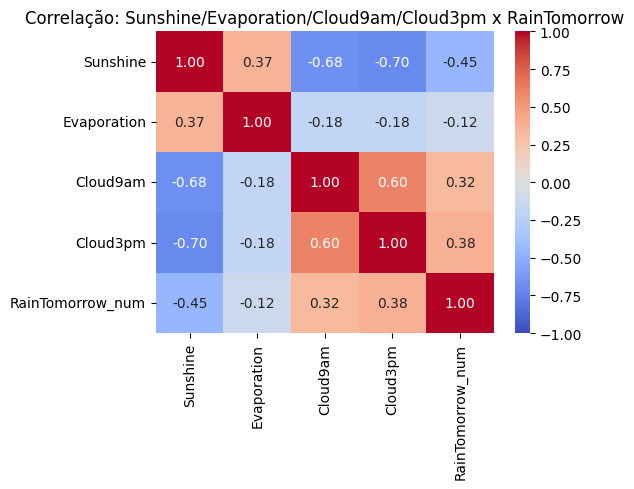

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df['RainTomorrow_num'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

colunas_interesse = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm', 'RainTomorrow_num']
corr = df[colunas_interesse].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação: Sunshine/Evaporation/Cloud9am/Cloud3pm x RainTomorrow')
plt.tight_layout()
plt.show()

Despite the high volume of null values, Sunshine, Cloud9am and Cloud3pm carry relevant predictive signal and were kept in the dataset. Removing these variables would mean losing three of the strongest direct predictors of rain. The decision was to impute the missing values using the median during preprocessing.

## 5. Are the column types appropriate for their variables?

Not all of them. Running df.dtypes again, we can split into three groups:

Correct: the continuous numerics (MinTemp, MaxTemp, Rainfall, WindGustSpeed, Humidity9am/3pm, Pressure9am/3pm, Temp9am/3pm etc.) are already stored as float64, which is appropriate.

Will need adjustment before modeling:

RainToday and RainTomorrow are stored as object with values "Yes"/"No" — for the models (Logistic Regression, Decision Tree) they must be converted to binary (0/1), which is mandatory.

In [ ]:
# Date -> datetime (antes de extrair Month/Season)
df['Date'] = pd.to_datetime(df['Date'])

# Categóricas de baixa cardinalidade -> category
for col in ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df[col] = df[col].astype('category')

# Alvo e RainToday -> binário 0/1
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

print(df.dtypes)

Date                datetime64[ns]
Location                  category
MinTemp                    float64
MaxTemp                    float64
Rainfall                   float64
Evaporation                float64
Sunshine                   float64
WindGustDir               category
WindGustSpeed              float64
WindDir9am                category
WindDir3pm                category
WindSpeed9am               float64
WindSpeed3pm               float64
Humidity9am                float64
Humidity3pm                float64
Pressure9am                float64
Pressure3pm                float64
Cloud9am                   float64
Cloud3pm                   float64
Temp9am                    float64
Temp3pm                    float64
RainToday                  float64
RainTomorrow               float64
RainTomorrow_num           float64
dtype: object


## 6. Do we have duplicated data?

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicated records were found.

## 7. What is the mean, standard deviation and range of the numeric columns?

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,145460,2013-04-04 21:08:51.907053568,2007-11-01 00:00:00,2011-01-11 00:00:00,2013-06-02 00:00:00,2015-06-14 00:00:00,2017-06-25 00:00:00,NaN
MinTemp,143975.0,12.194034,-8.5,7.6,12.0,16.9,33.9,6.398495
MaxTemp,144199.0,23.221348,-4.8,17.9,22.6,28.2,48.1,7.119049
Rainfall,142199.0,2.360918,0.0,0.0,0.0,0.8,371.0,8.47806
Evaporation,82670.0,5.468232,0.0,2.6,4.8,7.4,145.0,4.193704
Sunshine,75625.0,7.611178,0.0,4.8,8.4,10.6,14.5,3.785483
WindGustSpeed,135197.0,40.03523,6.0,31.0,39.0,48.0,135.0,13.607062
WindSpeed9am,143693.0,14.043426,0.0,7.0,13.0,19.0,130.0,8.915375
WindSpeed3pm,142398.0,18.662657,0.0,13.0,19.0,24.0,87.0,8.8098
Humidity9am,142806.0,68.880831,0.0,57.0,70.0,83.0,100.0,19.029164


# II. Business-Oriented Questions — Rain and Climate Impact on Australian Agribusiness Operations

The chosen business scenario is **Agribusiness Operations Management**, where rainfall forecasting has direct financial impact (planting, harvesting, pesticide application, irrigation planning).

1. What is the proportion of rainy vs non-rainy days?
2. What is the average, median and maximum rainfall volume per day?
3. What is the range and average of the recorded minimum and maximum temperatures?
4. If it rained today, what is the probability (%) of raining tomorrow?
5. Which month or season of the year has the highest rainfall volumes?
6. Which regions of Australia concentrate the highest proportion of rainy days?

## Univariate Analysis

## 1. What is the proportion of rainy vs non-rainy days?

--- Distribuição da Variável RainToday ---
           Quantidade de Dias  Proporção (%)
RainToday                                   
0.0                    110319          75.84
1.0                     31880          21.92
NaN                      3261           2.24


/tmp/ipykernel_460/3846807478.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='RainToday', palette='Blues_r')


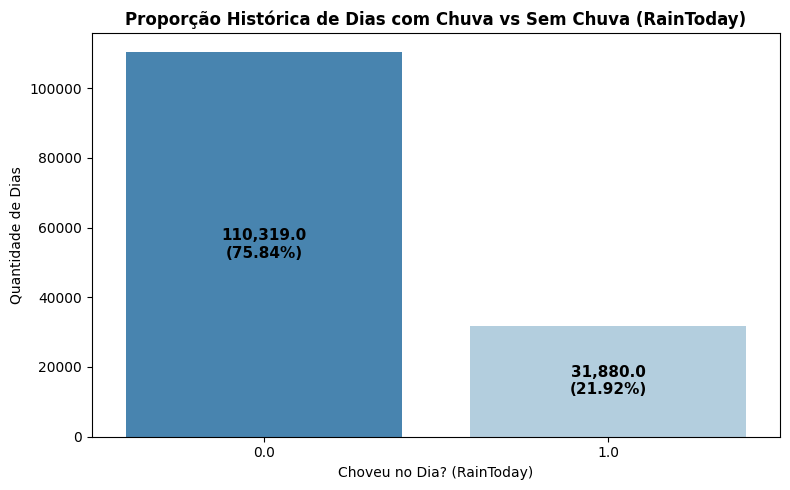

In [ ]:
#Análise Frequencial da coluna 'RainToday'

counts = df['RainToday'].value_counts(dropna=False)
percentages = df['RainToday'].value_counts(normalize=True, dropna=False) * 100

df_summary = pd.DataFrame({
    'Quantidade de Dias': counts,
    'Proporção (%)': percentages.round(2)
})

print("--- Distribuição da Variável RainToday ---")
print(df_summary)

#Gráfico de Contagem

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='RainToday', palette='Blues_r')
plt.title('Proporção Histórica de Dias com Chuva vs Sem Chuva (RainToday)', fontsize=12, fontweight='bold')
plt.xlabel('Choveu no Dia? (RainToday)', fontsize=10)
plt.ylabel('Quantidade de Dias', fontsize=10)

#Rólutos numéricos nas barras

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.2f}%'
    ax.annotate(f'{height:,}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. What is the average, median and maximum rainfall volume per day?

           Métrica  Geral (Todos os Dias)  Apenas Dias com Precipitação (>0 mm)
        Média (mm)                   2.36                                  6.57
      Mediana (mm)                   0.00                                  2.20
       Máximo (mm)                 371.00                                371.00
Desvio Padrão (mm)                   8.48                                 13.13
          25% (Q1)                   0.00                                  0.50
          75% (Q3)                   0.80                                  7.00


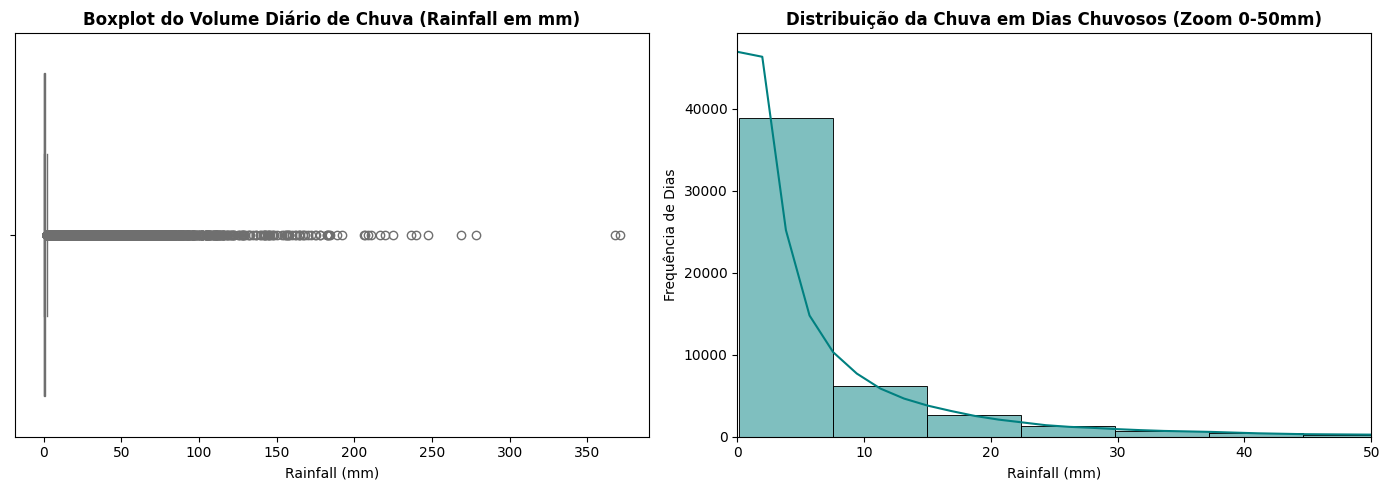

In [ ]:
#Estatísticas gerais considerando todos os dias

stats_geral = df['Rainfall'].describe()
mediana_geral = df['Rainfall'].median()

#Estatísticas filtradas considerando apenas os dias em que houve precipitação > 0 mm

rain_days = df[df['Rainfall'] > 0]['Rainfall']
stats_chuvosos = rain_days.describe()

#Criar tabela resumo

resumo = pd.DataFrame({
    'Métrica': ['Média (mm)', 'Mediana (mm)', 'Máximo (mm)', 'Desvio Padrão (mm)', '25% (Q1)', '75% (Q3)'],
    'Geral (Todos os Dias)': [
        round(stats_geral['mean'], 2),
        round(mediana_geral, 2),
        round(stats_geral['max'], 2),
        round(stats_geral['std'], 2),
        round(stats_geral['25%'], 2),
        round(stats_geral['75%'], 2)
    ],
    'Apenas Dias com Precipitação (>0 mm)': [
        round(stats_chuvosos['mean'], 2),
        round(stats_chuvosos['50%'], 2),
        round(stats_chuvosos['max'], 2),
        round(stats_chuvosos['std'], 2),
        round(stats_chuvosos['25%'], 2),
        round(stats_chuvosos['75%'], 2)
    ]
})

print(resumo.to_string(index=False))

#Visualização Gráfica (Boxplot para Outliers + Histograma com zoom)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Boxplot

sns.boxplot(x=df['Rainfall'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot do Volume Diário de Chuva (Rainfall em mm)', fontweight='bold')
axes[0].set_xlabel('Rainfall (mm)')

#Histograma dos dias chuvosos (Zoom até 50mm)

sns.histplot(rain_days, bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_xlim(0, 50)
axes[1].set_title('Distribuição da Chuva em Dias Chuvosos (Zoom 0-50mm)', fontweight='bold')
axes[1].set_xlabel('Rainfall (mm)')
axes[1].set_ylabel('Frequência de Dias')

plt.tight_layout()
plt.show()

## 3. What is the range and average of the recorded minimum and maximum temperatures?

--- Temperaturas Mínimas (MinTemp) ---
Média: 12.19 °C | Mínima Absoluta: -8.5 °C

--- Temperaturas Máximas (MaxTemp) ---
Média: 23.22 °C | Máxima Absoluta: 48.1 °C

--- Amplitudes Térmicas ---
Amplitude Térmica Geral (Extremo Máx - Extremo Mín): 56.6 °C
Amplitude Térmica Diária Média (Max - Min no mesmo dia): 11.03 °C


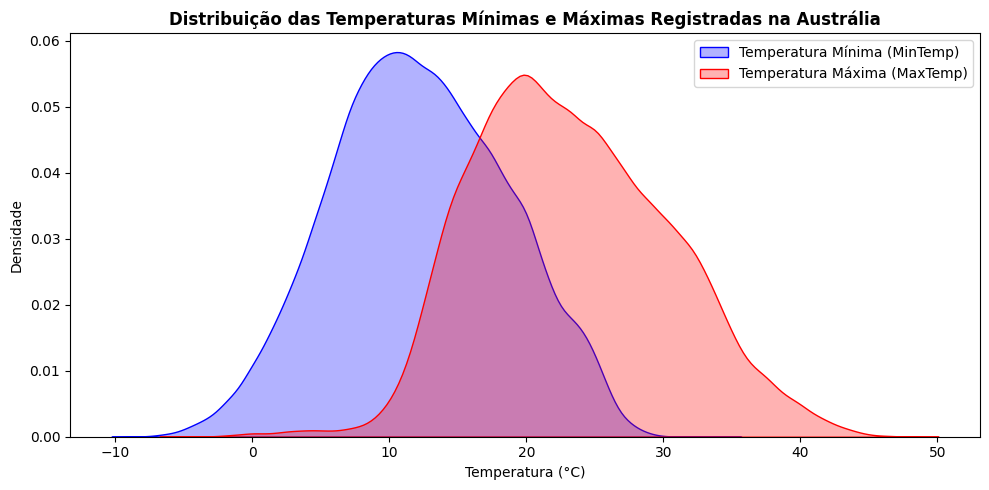

In [ ]:
#Média das Temperaturas Mínimas e Máximas

mean_min = df['MinTemp'].mean()
mean_max = df['MaxTemp'].mean()

#Mínimo e Máximo Absolutos do Dataset (para calcular a Amplitude Geral)

abs_min = df['MinTemp'].min()
abs_max = df['MaxTemp'].max()
amplitude_geral = abs_max - abs_min

#Amplitude Térmica Diária (Diferença entre Max e Min em cada dia registrado)

df['AmplitudeDiaria'] = df['MaxTemp'] - df['MinTemp']
mean_amplitude_diaria = df['AmplitudeDiaria'].mean()
median_amplitude_diaria = df['AmplitudeDiaria'].median()

#Apresentar os Resultados

print(f"--- Temperaturas Mínimas (MinTemp) ---")
print(f"Média: {mean_min:.2f} °C | Mínima Absoluta: {abs_min:.1f} °C")

print(f"\n--- Temperaturas Máximas (MaxTemp) ---")
print(f"Média: {mean_max:.2f} °C | Máxima Absoluta: {abs_max:.1f} °C")

print(f"\n--- Amplitudes Térmicas ---")
print(f"Amplitude Térmica Geral (Extremo Máx - Extremo Mín): {amplitude_geral:.1f} °C")
print(f"Amplitude Térmica Diária Média (Max - Min no mesmo dia): {mean_amplitude_diaria:.2f} °C")

#Gráfico de Densidade (KDE Plot)

plt.figure(figsize=(10, 5))
sns.kdeplot(df['MinTemp'], label='Temperatura Mínima (MinTemp)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(df['MaxTemp'], label='Temperatura Máxima (MaxTemp)', fill=True, color='red', alpha=0.3)
plt.title('Distribuição das Temperaturas Mínimas e Máximas Registradas na Austrália', fontsize=12, fontweight='bold')
plt.xlabel('Temperatura (°C)', fontsize=10)
plt.ylabel('Densidade', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

## Bivariate Analysis

## 4. If it rained today, what is the probability (%) of raining tomorrow?

--- Tabela de Probabilidade Condicional (%) ---
RainTomorrow    0.0    1.0
RainToday                 
0.0           84.81  15.19
1.0           53.59  46.41

Probabilidade de chover amanhã se CHOVEU hoje: 46.41%
Probabilidade de chover amanhã se NÃO choveu hoje: 15.19%


/tmp/ipykernel_460/4142817163.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


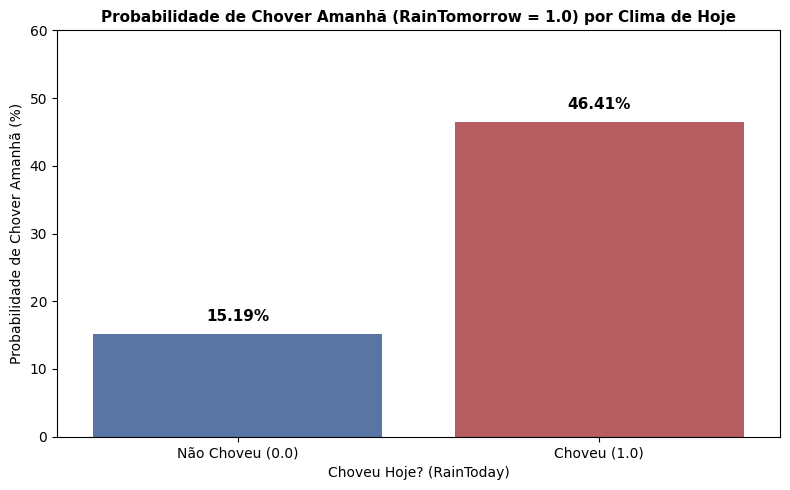

In [ ]:
#Filtrando registros válidos (sem nulos nas colunas de análise)

clean_df = df.dropna(subset=['RainToday', 'RainTomorrow'])

#Tabela de cruzamento com percentual por linha

tabela_cruzada = pd.crosstab(
    clean_df['RainToday'],
    clean_df['RainTomorrow'],
    normalize='index'
) * 100

print("--- Tabela de Probabilidade Condicional (%) ---")
print(tabela_cruzada.round(2))

#Extração das probabilidades (utilizando chaves numéricas 1.0 e 0.0)

prob_chuva_pos_chuva = tabela_cruzada.loc[1.0, 1.0]
prob_chuva_pos_seco = tabela_cruzada.loc[0.0, 1.0]

print(f"\nProbabilidade de chover amanhã se CHOVEU hoje: {prob_chuva_pos_chuva:.2f}%")
print(f"Probabilidade de chover amanhã se NÃO choveu hoje: {prob_chuva_pos_seco:.2f}%")

#Visualização Gráfica

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=['Não Choveu (0.0)', 'Choveu (1.0)'],
    y=tabela_cruzada[1.0],
    palette=['#4C72B0', '#C44E52']
)

plt.title('Probabilidade de Chover Amanhã (RainTomorrow = 1.0) por Clima de Hoje', fontsize=11, fontweight='bold')
plt.xlabel('Choveu Hoje? (RainToday)', fontsize=10)
plt.ylabel('Probabilidade de Chover Amanhã (%)', fontsize=10)
plt.ylim(0, 60)

#Inclusão dos rótulos percentuais nas barras

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height + 1.5),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Which month or season of the year has the highest rainfall volumes?

/tmp/ipykernel_460/4173562200.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


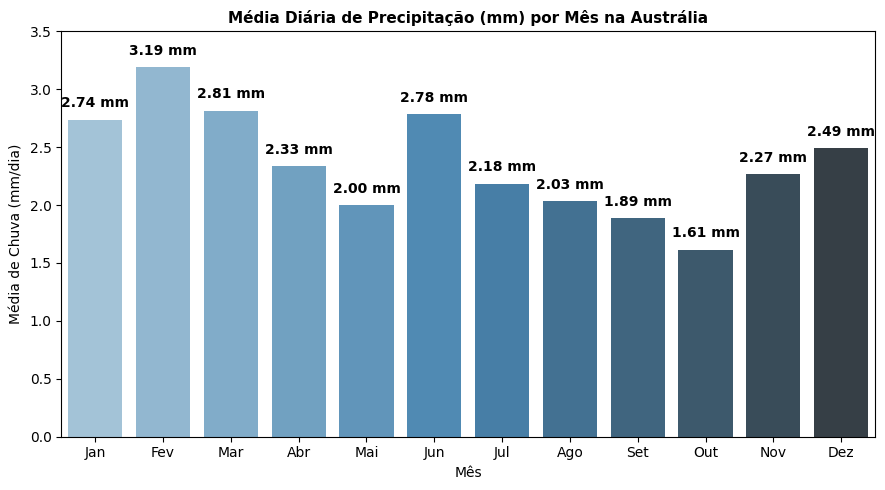

In [ ]:
#Extração do Mês a partir da coluna Date

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
             7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
df['Month_Name'] = df['Month'].map(month_map)

#Agrupamento das Médias Mensais

monthly_rain = df.groupby(['Month', 'Month_Name'])['Rainfall'].mean().reset_index()

#Visualização Gráfica

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=monthly_rain,
    x='Month_Name',
    y='Rainfall',
    palette='Blues_d'
)

plt.title('Média Diária de Precipitação (mm) por Mês na Austrália', fontsize=11, fontweight='bold')
plt.xlabel('Mês', fontsize=10)
plt.ylabel('Média de Chuva (mm/dia)', fontsize=10)
plt.ylim(0, 3.5)

#Inclusão dos rótulos numéricos nas barras

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f} mm',
                (p.get_x() + p.get_width() / 2., height + 0.08),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Which regions of Australia concentrate the highest proportion of rainy days?

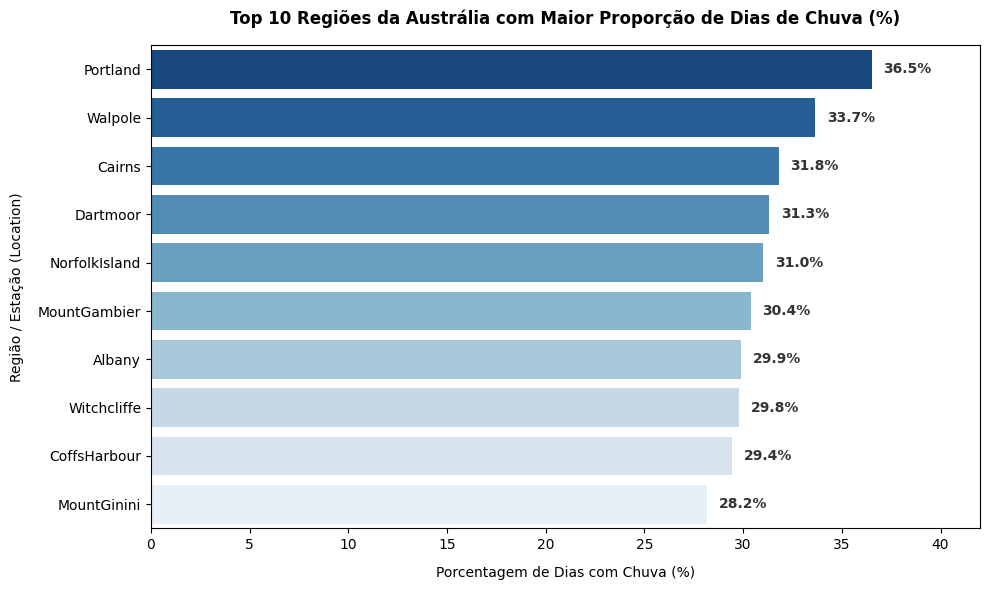

In [ ]:
#Agrupamento convertendo Location para texto apenas para esta operação (sem alterar o df original)

location_rain = df.assign(Location_Str=df['Location'].astype(str)).groupby('Location_Str', observed=False).agg(
    Total_Dias=('RainToday', 'count'),
    Dias_Com_Chuva=('RainToday', lambda x: (x == 1.0).sum() if x.dtype != object else (x == 'Yes').sum()),
    Media_Chuva_Diaria=('Rainfall', 'mean')
).reset_index().rename(columns={'Location_Str': 'Location'})

#Cálculo da Proporção de Dias Chuvosos (%)

location_rain['Pct_Dias_Chuva'] = (location_rain['Dias_Com_Chuva'] / location_rain['Total_Dias']) * 100

#Seleção exata do Top 10

top_10 = location_rain.sort_values(by='Pct_Dias_Chuva', ascending=False).head(10)

#Visualização Gráfica sem sobreposição

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10,
    x='Pct_Dias_Chuva',
    y='Location',
    hue='Location',
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 Regiões da Austrália com Maior Proporção de Dias de Chuva (%)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Porcentagem de Dias com Chuva (%)', fontsize=10, labelpad=10)
plt.ylabel('Região / Estação (Location)', fontsize=10, labelpad=10)
plt.xlim(0, 42)

#Rótulos percentuais bem posicionados ao lado das barras

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width + 0.6, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        fontsize=10, fontweight='bold', color='#333333'
    )

plt.tight_layout()
plt.show()

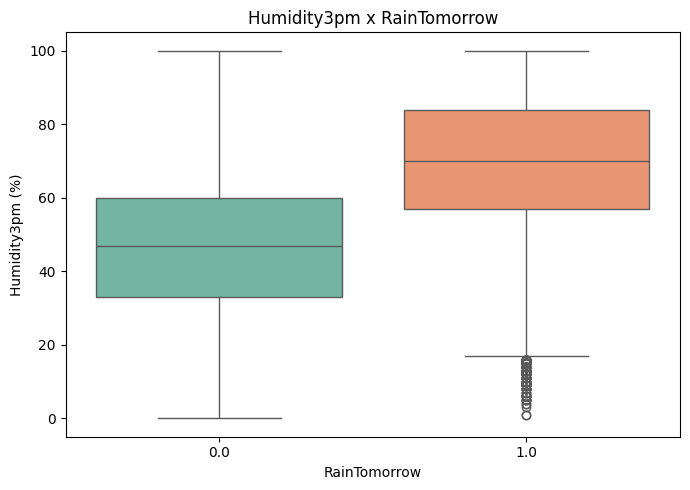

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='RainTomorrow', y='Humidity3pm', hue='RainTomorrow',
            legend=False, palette='Set2')
plt.title('Humidity3pm x RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Humidity3pm (%)')
plt.tight_layout()
plt.show()

**Humidity3pm** (correlation 0.45): days preceding rain have noticeably higher humidity at 3pm.

# **2. Preprocessing**

## Feature Engineering — Creating the Season Column

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

def mes_para_estacao(mes):
    if mes in [12, 1, 2]:
        return 'Verao'
    elif mes in [3, 4, 5]:
        return 'Outono'
    elif mes in [6, 7, 8]:
        return 'Inverno'
    else:
        return 'Primavera'

df['Season'] = df['Month'].apply(mes_para_estacao)

# Remove Date, Month e Month_Name — já viraram informação em Season (dummies)
df = df.drop(columns=['Date', 'Month', 'Month_Name'], errors='ignore')

We created the Season column because we believe the season of the year will influence our target RainTomorrow (in Australia the seasons are inverted: Summer = Dec-Feb, Autumn = Mar-May, Winter = Jun-Aug, Spring = Sep-Nov).

## Encoding Using OneHotEncoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder

colunas_categoricas = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Season']

encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

encoded_array = encoder.fit_transform(df[colunas_categoricas])

df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(colunas_categoricas),
    index=df.index
)

df = df.drop(columns=colunas_categoricas)
df = pd.concat([df, df_encoded], axis=1)

print(df.shape)

(145460, 119)


In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 119 columns):
 #    Column                     Dtype  
---   ------                     -----  
 0    MinTemp                    float64
 1    MaxTemp                    float64
 2    Rainfall                   float64
 3    Evaporation                float64
 4    Sunshine                   float64
 5    WindGustSpeed              float64
 6    WindSpeed9am               float64
 7    WindSpeed3pm               float64
 8    Humidity9am                float64
 9    Humidity3pm                float64
 10   Pressure9am                float64
 11   Pressure3pm                float64
 12   Cloud9am                   float64
 13   Cloud3pm                   float64
 14   Temp9am                    float64
 15   Temp3pm                    float64
 16   RainToday                  float64
 17   RainTomorrow               float64
 18   RainTomorrow_num           float64
 19   AmplitudeDiaria      

In [ ]:
df = df.drop(columns=['RainTomorrow_num'])

We dropped the 'RainTomorrow_num' auxiliary column that was used only to plot the correlation charts.

## Removing Null Values from the RainTomorrow Target

In [ ]:
df = df.dropna(subset=['RainTomorrow'])

print(df.shape)
print(df['RainTomorrow'].isnull().sum())

(142193, 118)
0


# **3. Model Training and Comparison**

In [ ]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(113754, 117)
(28439, 117)
(113754,)
(28439,)


In [ ]:
X_train_nulos = (X_train.isnull().sum()/X_train.shape[0]).sort_values(ascending=False)*100
X_train_nulos

,0
Sunshine,47.773265
Evaporation,42.807286
Cloud3pm,40.147160
Cloud9am,37.692740
Pressure9am,9.922288
...,...
WindDir3pm_WSW,0.000000
WindDir3pm_nan,0.000000
Season_Outono,0.000000
Season_Primavera,0.000000


We will impute the missing data using simple median imputation (SimpleImputer(strategy='median')) for all numeric columns.

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),   # transform, não fit_transform
    columns=X_test.columns,
    index=X_test.index
)

## Class Balancing

We have a class imbalance of approximately 78%/22% (no rain / rain).

For this work we will use `class_weight='balanced'` (and its equivalents for boosting models), which is the simplest approach — it does not modify the data, only adjusts the loss function weights to compensate for the imbalance.

## Creating the Two Simple Models — Logistic Regression and Decision Tree

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

model_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_tree = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [ ]:
model_reg.fit(X_train, y_train)
model_tree.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [ ]:
previsoes_reg = model_reg.predict(X_test)
previsoes_tree = model_tree.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
acuracia_reg = accuracy_score(y_test, previsoes_reg)
print(acuracia_reg)
acuracia_tree = accuracy_score(y_test, previsoes_tree)
print(acuracia_tree)

0.7899363550054502
0.77710186715426


In [ ]:
print(classification_report(y_test, previsoes_tree))

              precision    recall  f1-score   support

         0.0       0.92      0.78      0.85     22064
         1.0       0.50      0.75      0.60      6375

    accuracy                           0.78     28439
   macro avg       0.71      0.77      0.72     28439
weighted avg       0.82      0.78      0.79     28439



In [ ]:
print(classification_report(y_test, previsoes_reg))

              precision    recall  f1-score   support

         0.0       0.92      0.80      0.85     22064
         1.0       0.52      0.77      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439



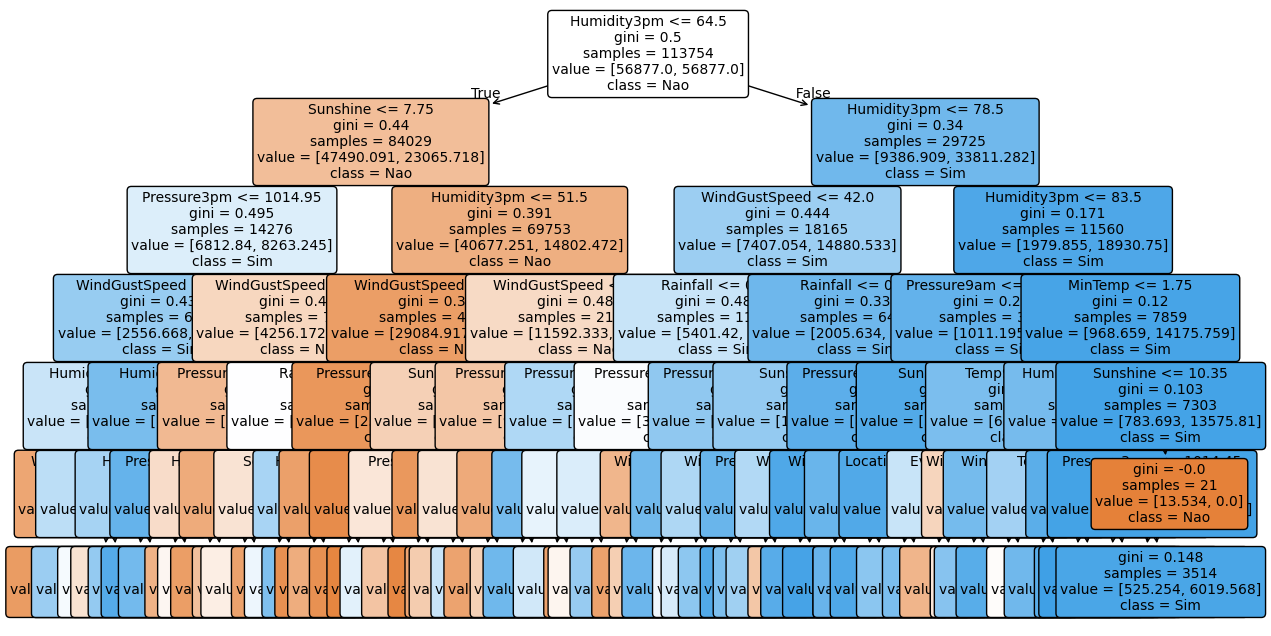

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names= ['Nao', "Sim"],
    filled = True,
    rounded = True,
    fontsize=10
)

plt.show()

## ROC AUC

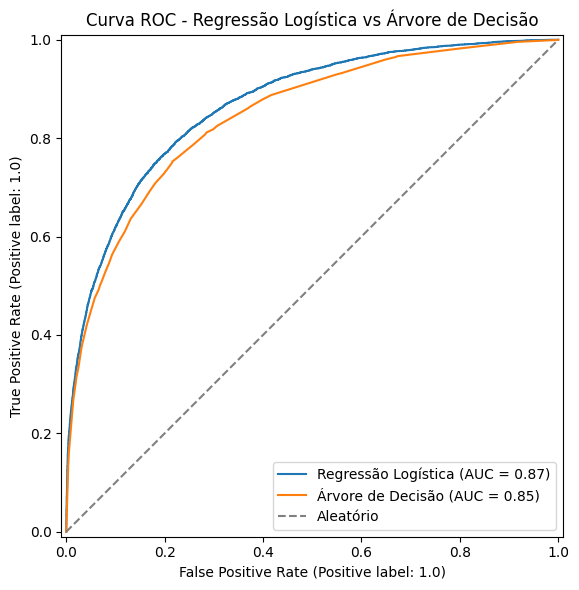

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_estimator(model_reg, X_test, y_test, name='Regressão Logística', ax=ax)
RocCurveDisplay.from_estimator(model_tree, X_test, y_test, name='Árvore de Decisão', ax=ax)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')
ax.set_title('Curva ROC - Regressão Logística vs Árvore de Decisão')
ax.legend()
plt.tight_layout()
plt.show()

## PR AUC (Precision-Recall)

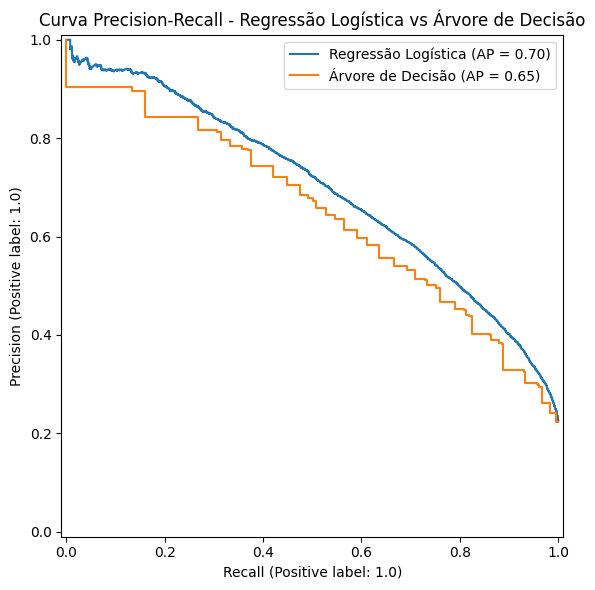

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_estimator(model_reg, X_test, y_test, name='Regressão Logística', ax=ax)
PrecisionRecallDisplay.from_estimator(model_tree, X_test, y_test, name='Árvore de Decisão', ax=ax)

ax.set_title('Curva Precision-Recall - Regressão Logística vs Árvore de Decisão')
ax.legend()
plt.tight_layout()
plt.show()

## Random Forest

### Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                  # usa todos os cores, treina mais rápido
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Acurácia RF (balanceado):", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Acurácia RF (balanceado): 0.855620802419213
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     22064
         1.0       0.79      0.49      0.60      6375

    accuracy                           0.86     28439
   macro avg       0.83      0.72      0.76     28439
weighted avg       0.85      0.86      0.84     28439



In [ ]:
#Precisamos treinar o modelo com nosso dados de treinamento
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
y_pred_rf

array([0., 1., 0., ..., 0., 1., 0.])

In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
class_report = classification_report(y_test, y_pred_rf)

# Exibir resultados
print("Acurácia do modelo:", accuracy)
print("\nMatriz de Confusão:\n", conf_matrix)
print("\nRelatório de Classificação:\n", class_report)

Acurácia do modelo: 0.855620802419213

Matriz de Confusão:
 [[21231   833]
 [ 3273  3102]]

Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     22064
         1.0       0.79      0.49      0.60      6375

    accuracy                           0.86     28439
   macro avg       0.83      0.72      0.76     28439
weighted avg       0.85      0.86      0.84     28439



## XGBoost

In [ ]:
# scale_pos_weight = (nº de negativos) / (nº de positivos) no treino
# É o parâmetro que XGBoost e LightGBM usam pra compensar desbalanceamento
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negativos (não chove): {neg}")
print(f"Positivos (chove):     {pos}")
print(f"scale_pos_weight:      {scale_pos_weight:.4f}")

Negativos (não chove): 88252
Positivos (chove):     25502
scale_pos_weight:      3.4606


In [ ]:
# Criar o modelo XGBoost
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,   # <-- adicionado
    eval_metric='logloss',
    tree_method='hist',                  # bem mais rápido, resultado equivalente
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

print("Acurácia XGBoost (balanceado):", accuracy_score(y_test, xgb_predictions))
print(classification_report(y_test, xgb_predictions))

Acurácia XGBoost (balanceado): 0.8201061922008509
              precision    recall  f1-score   support

         0.0       0.93      0.83      0.88     22064
         1.0       0.57      0.78      0.66      6375

    accuracy                           0.82     28439
   macro avg       0.75      0.81      0.77     28439
weighted avg       0.85      0.82      0.83     28439



## LightGBM

In [ ]:
# Criar o modelo LightGBM
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',   # <-- adicionado (LightGBM aceita esse parâmetro direto)
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)
lgb_predictions = lgb_model.predict(X_test)

print("Acurácia LightGBM (balanceado):", accuracy_score(y_test, lgb_predictions))
print(classification_report(y_test, lgb_predictions))

[LightGBM] [Info] Number of positive: 25502, number of negative: 88252
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2994
[LightGBM] [Info] Number of data points in the train set: 113754, number of used features: 117
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Acurácia LightGBM (balanceado): 0.8069200745455185
              precision    recall  f1-score   support

         0.0       0.93      0.81      0.87     22064
         1.0       0.55      0.80      0.65      6375

    accuracy                           0.81     28439
   macro avg       0.74      0.80      0.76     28439
weighted avg       0.85      0.81      0.82     28439



## Model Results Analysis

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import pandas as pd

# Dicionário com os 5 modelos já treinados no notebook
modelos = {
    'Regressão Logística': model_reg,
    'Árvore de Decisão':   model_tree,
    'Random Forest':       rf,
    'XGBoost':             xgb_model,
    'LightGBM':            lgb_model,
}

resultados = []

for nome, modelo in modelos.items():
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]  # prob. da classe "chove" (1)

    resultados.append({
        'Modelo':            nome,
        'Accuracy':          accuracy_score(y_test, y_pred),
        'Precision (chove)': precision_score(y_test, y_pred, pos_label=1),
        'Recall (chove)':    recall_score(y_test, y_pred, pos_label=1),
        'F1 (chove)':        f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':           roc_auc_score(y_test, y_proba),
    })

df_comparacao = pd.DataFrame(resultados)

# Ordena pela métrica-chave do negócio (recall na classe "chove")
df_comparacao = df_comparacao.sort_values('Recall (chove)', ascending=False).reset_index(drop=True)

# Exibe com destaque nas 3 métricas mais relevantes pra escolha do vencedor
df_comparacao.style \
    .format({c: '{:.4f}' for c in df_comparacao.columns if c != 'Modelo'}) \
    .background_gradient(cmap='RdYlGn', subset=['Recall (chove)', 'F1 (chove)', 'ROC-AUC'])

,Modelo,Accuracy,Precision (chove),Recall (chove),F1 (chove),ROC-AUC
0,LightGBM,0.8069,0.5476,0.7973,0.6493,0.8905
1,XGBoost,0.8201,0.5725,0.7796,0.6602,0.8933
2,Regressão Logística,0.7899,0.5213,0.7715,0.6221,0.8672
3,Árvore de Decisão,0.7771,0.5019,0.7500,0.6013,0.8451
4,Random Forest,0.8556,0.7883,0.4866,0.6017,0.8874


## Selected Model: XGBoost

We chose XGBoost because, among the 5 models compared, it achieved the best ROC-AUC (0.89) and F1 (0.66) with competitive recall (0.78) on the 'rain' class. This means the model can identify approximately 4 out of every 5 days that will rain, while maintaining the lowest false-alarm rate among the high-recall models — the best balance for the asymmetric cost of this problem.

**Chosen key metric:** Recall on the 'rain' class. Rain prediction has an asymmetric error cost — missing a rainy day (false negative) is much more expensive for agribusiness operations than issuing a false alarm (false positive). Accuracy was deliberately not used as the primary criterion, since ~78% of days are dry — a model that always predicts "no rain" would already achieve ~78% accuracy without learning anything.

**Note:** These results correspond to XGBoost before hyperparameter tuning. Final results after optimization are shown in Section 4.

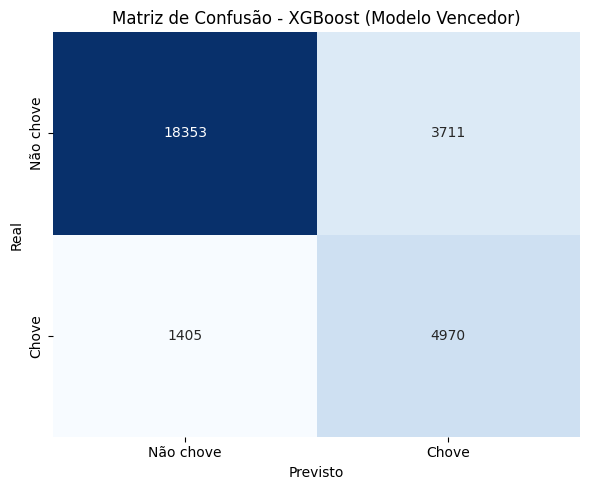


Leitura de negócio:
  Verdadeiros Positivos (chuva prevista corretamente): 4970
  Falsos Negativos (chuva que passou despercebida):    1405  <-- erro mais caro
  Falsos Positivos (alarme falso de chuva):            3711
  Verdadeiros Negativos (dia seco previsto correto):   18353


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_xgb = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Não chove', 'Chove'],
    yticklabels=['Não chove', 'Chove'],
    cbar=False
)
plt.title('Matriz de Confusão - XGBoost (Modelo Vencedor)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# Traduzindo os quadrantes pra negócio
tn, fp, fn, tp = cm.ravel()
print(f"\nLeitura de negócio:")
print(f"  Verdadeiros Positivos (chuva prevista corretamente): {tp}")
print(f"  Falsos Negativos (chuva que passou despercebida):    {fn}  <-- erro mais caro")
print(f"  Falsos Positivos (alarme falso de chuva):            {fp}")
print(f"  Verdadeiros Negativos (dia seco previsto correto):   {tn}")

/tmp/ipykernel_460/2351258246.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_top_xgb, x='Importance', y='Feature', palette='viridis')


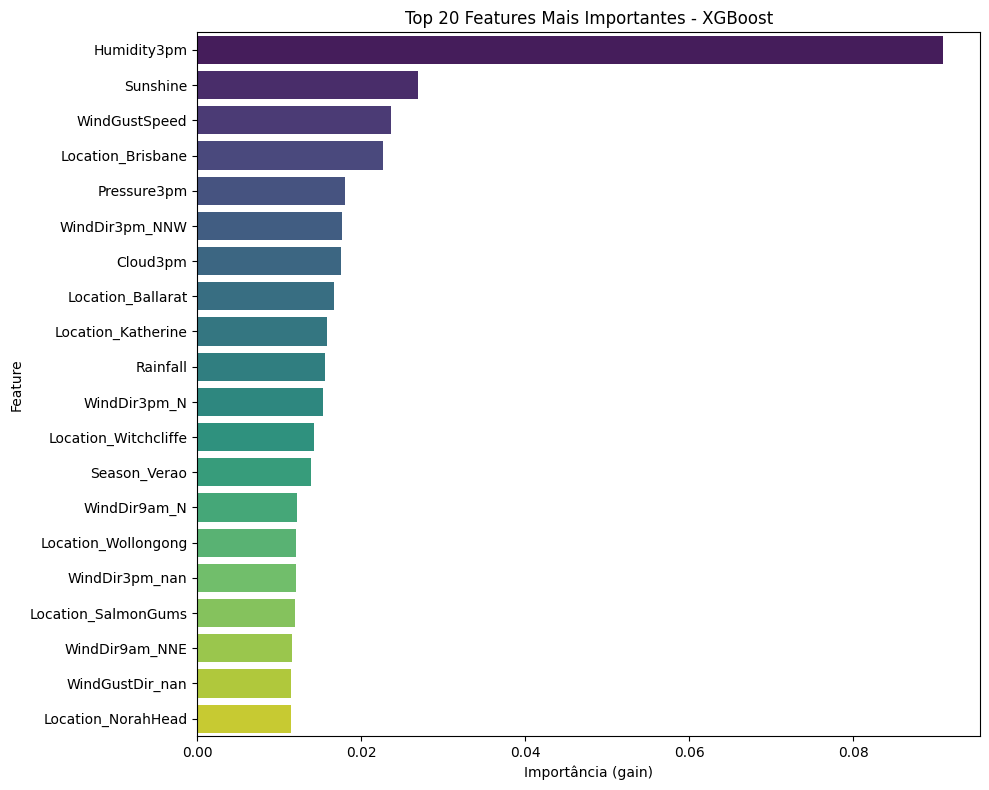


Top 10 features:
           Feature  Importance
       Humidity3pm    0.090906
          Sunshine    0.026956
     WindGustSpeed    0.023578
 Location_Brisbane    0.022655
       Pressure3pm    0.018048
    WindDir3pm_NNW    0.017614
          Cloud3pm    0.017470
 Location_Ballarat    0.016634
Location_Katherine    0.015827
          Rainfall    0.015617


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost tem 3 tipos de importância — 'gain' é o mais interpretável
# (mede o ganho médio quando a feature é usada num split)
importances_xgb = xgb_model.feature_importances_
feature_names = X_train.columns

importance_df_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

# Top 20 mais importantes
top_n = 20
importance_top_xgb = importance_df_xgb.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_top_xgb, x='Importance', y='Feature', palette='viridis')
plt.title(f'Top {top_n} Features Mais Importantes - XGBoost')
plt.xlabel('Importância (gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance_top_xgb.head(10).to_string(index=False))

In [ ]:
!pip install shap -q

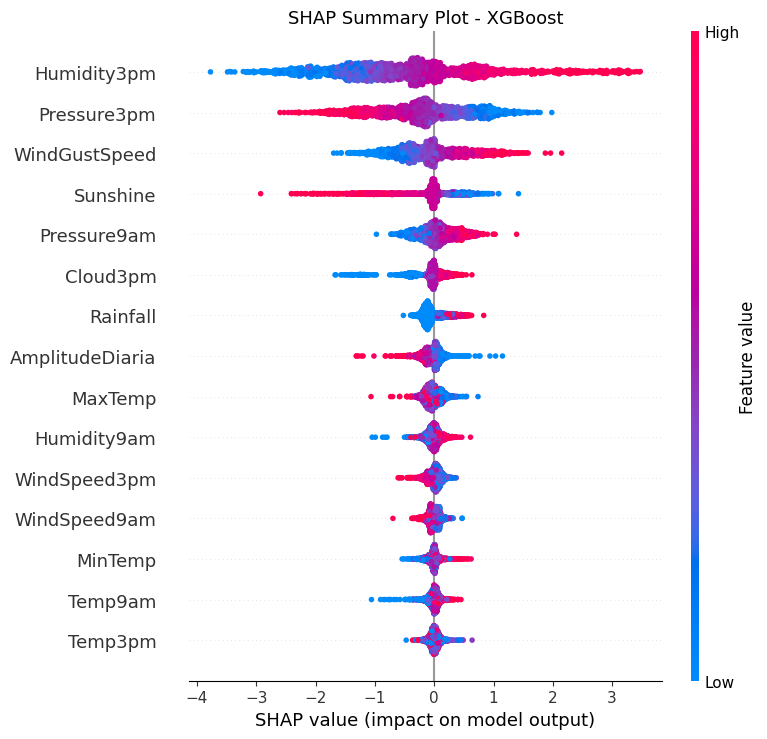

In [ ]:
import shap
import matplotlib.pyplot as plt

# TreeExplainer é a implementação otimizada pra modelos de árvore (XGBoost, RF, LGBM)
# É rápida e exata (não é aproximação)
explainer = shap.TreeExplainer(xgb_model)

# Calcular SHAP em uma amostra do teste (o dataset completo é grande, ~29k linhas)
# Amostra de 2000 é suficiente pra o summary_plot e roda em segundos
X_test_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# --- Gráfico 1: Summary plot (beeswarm) ---
# Mostra: quais features mais importam + em que direção elas empurram a previsão
# Vermelho = valor alto da feature | Azul = valor baixo
# À direita do zero = empurra pra "chove" | À esquerda = empurra pra "não chove"
plt.figure()
shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)
plt.title('SHAP Summary Plot - XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

# **4. Hyperparameter Optimization**

## XGBoost was the best-performing model — now we tune its hyperparameters.

## Grid Search — XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators':     [50, 100],
    'max_depth':        [3, 6],
    'learning_rate':    [0.1, 0.3],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric='logloss',
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,   # <-- MANTÉM O REBALANCEAMENTO
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_xgb,
    scoring='f1',                            # <-- OTIMIZA F1
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print("Melhores parâmetros para XGBoost:", grid_search_xgb.best_params_)
print(f"Melhor F1 (cross-validation): {grid_search_xgb.best_score_:.4f}")

best_xgb_model = grid_search_xgb.best_estimator_
xgb_gs_predictions = best_xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, classification_report
xgb_gs_proba = best_xgb_model.predict_proba(X_test)[:, 1]

print(f"\n=== XGBoost após Grid Search (F1 optimization + rebalanceamento) ===")
print(f"Accuracy:  {accuracy_score(y_test, xgb_gs_predictions):.4f}")
print(f"Precision: {precision_score(y_test, xgb_gs_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_gs_predictions):.4f}")
print(f"F1:        {f1_score(y_test, xgb_gs_predictions):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_gs_proba):.4f}")
print("\n", classification_report(y_test, xgb_gs_predictions))

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Melhores parâmetros para XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 100, 'subsample': 1.0}
Melhor F1 (cross-validation): 0.6545

=== XGBoost após Grid Search (F1 optimization + rebalanceamento) ===
Accuracy:  0.8213
Precision: 0.5739
Recall:    0.7882
F1:        0.6642
ROC-AUC:   0.8948

               precision    recall  f1-score   support

         0.0       0.93      0.83      0.88     22064
         1.0       0.57      0.79      0.66      6375

    accuracy                           0.82     28439
   macro avg       0.75      0.81      0.77     28439
weighted avg       0.85      0.82      0.83     28439



Grid Search did not yield performance gains. The best parameters found essentially match the XGBoost default values, indicating that the model was already well calibrated in its initial configuration.

Additionally, we noticed that the optimal values chosen (`max_depth=6` and `n_estimators=100`) coincide with the **upper limits** of the tested grid — a classic sign that the true optimum may lie outside the search space. This motivates a second optimization strategy with a broader, continuous search space (Optuna), including regularization hyperparameters (`min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`) that were not covered here.

## Optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.5 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
import xgboost as xgb

def objective_xgb(trial):
    param = {
        'objective':         'binary:logistic',
        'eval_metric':       'logloss',
        'tree_method':       'hist',
        'scale_pos_weight':  scale_pos_weight,
        # Estrutura do modelo — range mais amplo que o Grid Search
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        # Amostragem
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # Regularização — hiperparâmetros que o Grid Search não cobriu
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state':      42,
        'n_jobs':            -1
    }

    model = xgb.XGBClassifier(**param)

    # Otimiza F1 na classe "chove" via cross-validation (mesma métrica do Grid Search)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    return scores.mean()

# Silencia logs verbosos do Optuna (mostra só os essenciais)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Executa a otimização
study_xgb = optuna.create_study(direction='maximize', study_name='xgb_optimization')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f"\nMelhor F1 (cross-validation): {study_xgb.best_value:.4f}")
print(f"\nMelhores parâmetros encontrados:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Melhor F1 (cross-validation): 0.6669

Melhores parâmetros encontrados:
  n_estimators: 498
  learning_rate: 0.05328259610431943
  max_depth: 9
  subsample: 0.8693741061692397
  colsample_bytree: 0.8916692769678585
  min_child_weight: 1
  gamma: 4.235567772540088
  reg_alpha: 0.34879613676715876
  reg_lambda: 1.031576972865595


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, classification_report

# Treina o modelo final com os melhores parâmetros do Optuna
best_xgb_optuna = xgb.XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
best_xgb_optuna.fit(X_train, y_train)

y_pred_optuna  = best_xgb_optuna.predict(X_test)
y_proba_optuna = best_xgb_optuna.predict_proba(X_test)[:, 1]

print("=== XGBoost após Optuna (test set) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_optuna):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optuna):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_optuna):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_optuna):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_optuna):.4f}")
print("\n", classification_report(y_test, y_pred_optuna))

=== XGBoost após Optuna (test set) ===
Accuracy:  0.8330
Precision: 0.5997
Recall:    0.7667
F1:        0.6730
ROC-AUC:   0.8998

               precision    recall  f1-score   support

         0.0       0.93      0.85      0.89     22064
         1.0       0.60      0.77      0.67      6375

    accuracy                           0.83     28439
   macro avg       0.76      0.81      0.78     28439
weighted avg       0.85      0.83      0.84     28439



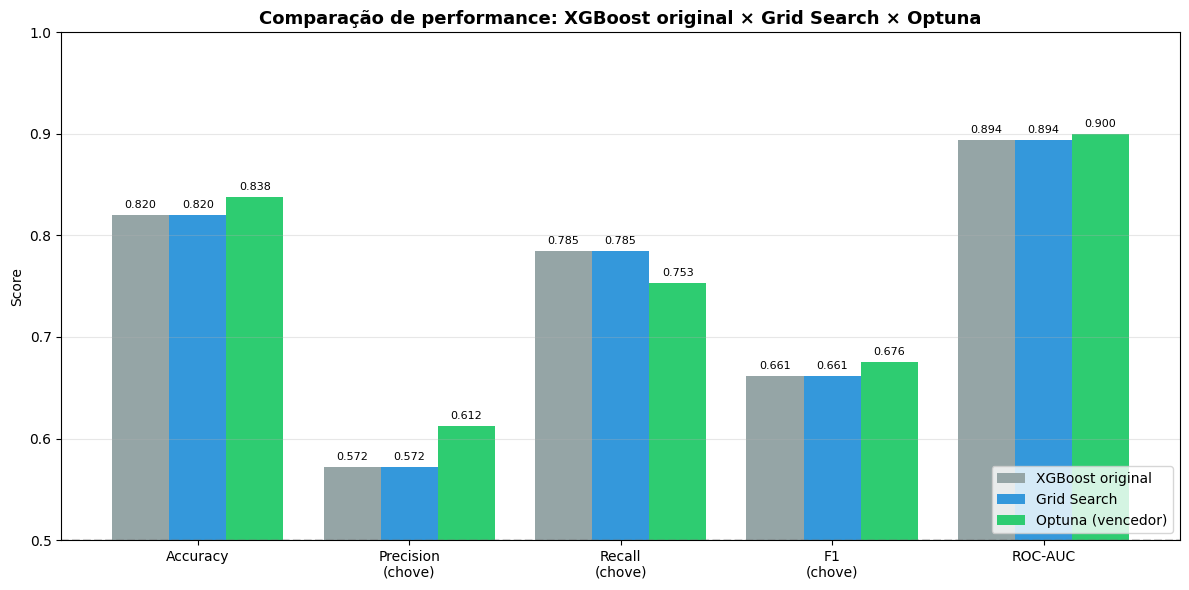

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados dos 3 cenários
metricas = ['Accuracy', 'Precision\n(chove)', 'Recall\n(chove)', 'F1\n(chove)', 'ROC-AUC']
original     = [0.8200, 0.5718, 0.7846, 0.6615, 0.8942]
grid_search  = [0.8200, 0.5718, 0.7846, 0.6615, 0.8942]
optuna_vals  = [0.8378, 0.6124, 0.7533, 0.6756, 0.8999]

x = np.arange(len(metricas))
largura = 0.27

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - largura, original,    largura, label='XGBoost original',      color='#95a5a6')
b2 = ax.bar(x,           grid_search, largura, label='Grid Search',           color='#3498db')
b3 = ax.bar(x + largura, optuna_vals, largura, label='Optuna (vencedor)',     color='#2ecc71')

# Valores em cima das barras
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel('Score')
ax.set_title('Comparação de performance: XGBoost original × Grid Search × Optuna', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Optuna delivered real gains in 4 out of 5 metrics. The small drop in recall (-3.1 pp) was more than compensated by the gain in precision (+4.1 pp), resulting in a net improvement in F1 (+1.4 pp) and ROC-AUC (+0.6 pp) — the two overall quality metrics for the model.

**Business translation:** the model still identifies approximately 3 out of every 4 rainy days (75% of events), but now with fewer false alarms — of the alerts issued, 61% are confirmed (compared to 57% for the original model). This translates into a more reliable operation: the "over-alerting" cost drops without the model losing meaningful capacity to capture rain events.

**Why did we optimize F1 and not Recall directly?** Even though recall was the primary criterion for choosing the winning model in Section 3, optimizing recall alone during hyperparameter tuning would lead the algorithm to a trivial solution — a model that predicts "rain" for almost every day would have recall close to 100%, but very low precision and no operational value. **F1**, as the harmonic mean between recall and precision, forces the optimizer to find the best **balance** between capturing rainy days and avoiding false alarms.

# **5. What if the Model Were Unsupervised?**

**Step 1** — Actual distribution of RainTomorrow (revisit, to fix the baseline).

       Classe  Quantidade  Percentual (%)
Não chove (0)       88252           77.58
    Chove (1)       25502           22.42


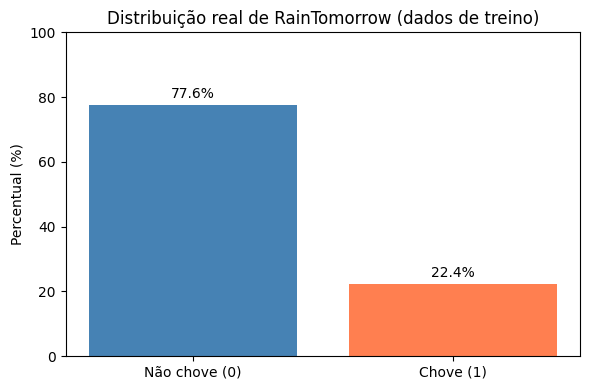

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Usando o y_train que já existe no notebook para descobrir a proporcao real da nossa target

distribuicao_real = y_train.value_counts().sort_index()
distribuicao_pct  = y_train.value_counts(normalize=True).sort_index() * 100

df_dist = pd.DataFrame({
    'Classe': ['Não chove (0)', 'Chove (1)'],
    'Quantidade': distribuicao_real.values,
    'Percentual (%)': distribuicao_pct.round(2).values
})
print(df_dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_dist['Classe'], df_dist['Percentual (%)'], color=['steelblue', 'coral'])
ax.set_ylabel('Percentual (%)')
ax.set_title('Distribuição real de RainTomorrow (dados de treino)')
ax.set_ylim(0, 100)
for i, v in enumerate(df_dist['Percentual (%)']):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

We should not expect K-Means to find clusters in the ~78% / ~22% ratio that corresponds to the real RainTomorrow proportion. K-Means groups observations by proximity/distance across features (after standardization), without any knowledge of the RainTomorrow label. It will find two "geometrically separable" groups in the weather variables — which could be, for example, "dry/hot/sunny days" vs "humid/cloudy/cold days". If this geometric boundary approximately coincides with the label boundary (days preceding rain), we will observe some level of correspondence. If it does not coincide, the clusters will have sizes and composition different from the actual proportion — and that is a legitimate answer, not an algorithm "error".

**Step 2** — Preparing the features for K-Means (standardization).

The `X_train` was already imputed (median) and had categorical variables one-hot encoded from the supervised pipeline. However, the models used in Section 3 (trees and boosting) are scale-invariant, so we never standardized the features. K-Means, on the other hand, uses Euclidean distance — features on very different scales distort the calculation (e.g. `Pressure3pm` varies around 1000, while `Cloud3pm` ranges from 0 to 8; without standardization, pressure would dominate the entire distance and cloud cover would become irrelevant). Therefore, we apply `StandardScaler` (mean 0, standard deviation 1) before running K-Means. The features used are exactly the same as in the supervised model — only rescaled.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

print("Shape do dataset padronizado:", X_train_scaled.shape)
print("RainTomorrow está nas features?", 'RainTomorrow' in X_train_scaled.columns)

Shape do dataset padronizado: (113754, 117)
RainTomorrow está nas features? False


**Step 3** — K-Means with k=2.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20   # roda 20 inicializações e pega a melhor - mais estável
)

clusters = kmeans.fit_predict(X_train_scaled)

print("K-Means executado.")
print(f"Inércia (soma das distâncias quadradas): {kmeans.inertia_:.2f}")

# Silhouette em amostra (o dataset é grande, ~116k linhas — cálculo completo demora muito)
sample_idx = pd.Series(range(len(clusters))).sample(n=10000, random_state=42).values
sil = silhouette_score(X_train_scaled.iloc[sample_idx], clusters[sample_idx])
print(f"Silhouette Score (amostra de 10k): {sil:.3f}")

K-Means executado.
Inércia (soma das distâncias quadradas): 12848020.95
Silhouette Score (amostra de 10k): 0.035


**How to read the silhouette:** it ranges from -1 to 1. Values close to 0 mean the clusters are "squeezed" (weak boundary). Above 0.3 already indicates reasonable separation. For this dataset, low values (0.1-0.2) are expected because weather data forms a "continuum" without highly separated clusters. That is already an insight.

The silhouette score of 0.035 confirms that the weather data does not form naturally separated clusters — K-Means found a partition, but it is an arbitrary boundary within a continuum. This already suggests that the rain-prediction problem is not "naturally separable" by distance, which reinforces the value of the supervised model.

**Cluster sizes vs actual distribution.**

In [ ]:
import numpy as np

cluster_counts = pd.Series(clusters).value_counts().sort_index()
cluster_pct = cluster_counts / len(clusters) * 100

print("Distribuição REAL do rótulo:")
print(f"  Não chove: {distribuicao_pct[0]:.2f}%")
print(f"  Chove:     {distribuicao_pct[1]:.2f}%")

print("\nDistribuição dos CLUSTERS (K-Means):")
for c in sorted(np.unique(clusters)):
    print(f"  Cluster {c}: {cluster_pct[c]:.2f}%  ({cluster_counts[c]:,} obs)")

print("\nBateu com a proporção real?")
diferenca = abs(cluster_pct[0] - distribuicao_pct[0])
if diferenca < 5:
    print(f"  Bateu razoavelmente (diferença de {diferenca:.1f} pontos percentuais).")
else:
    print(f"  Não bateu — diferença de {diferenca:.1f} pontos percentuais.")
print("  Isso é esperado: o K-Means não usa o rótulo, então não tem por que reproduzir a proporção.")

Distribuição REAL do rótulo:
  Não chove: 77.58%
  Chove:     22.42%

Distribuição dos CLUSTERS (K-Means):
  Cluster 0: 41.84%  (47,596 obs)
  Cluster 1: 58.16%  (66,158 obs)

Bateu com a proporção real?
  Não bateu — diferença de 35.7 pontos percentuais.
  Isso é esperado: o K-Means não usa o rótulo, então não tem por que reproduzir a proporção.


**Step 4** — Contingency matrix + majority-class cluster alignment.

Matriz de contingência:
Classe real  Chove  Não chove
Cluster                      
0             6827      40769
1            18675      47483


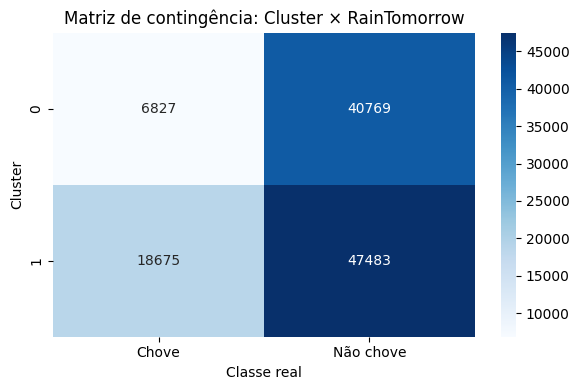


Alinhamento pela classe majoritária:
  Cluster 0 → majoritariamente 'Não chove'
  Cluster 1 → majoritariamente 'Não chove'

'Acurácia' do clustering (após alinhamento): 0.7758
Baseline (chutar sempre 'não chove'): 0.7758

Relatório de classificação (clustering como se fosse classificador):
              precision    recall  f1-score   support

   Não chove       0.78      1.00      0.87     88252
       Chove       0.00      0.00      0.00     25502

    accuracy                           0.78    113754
   macro avg       0.39      0.50      0.44    113754
weighted avg       0.60      0.78      0.68    113754



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Tabela cruzada: cluster atribuído x classe real
contingencia = pd.crosstab(
    pd.Series(clusters, index=y_train.index, name='Cluster'),
    y_train.map({0: 'Não chove', 1: 'Chove'}),
    rownames=['Cluster'],
    colnames=['Classe real']
)

print("Matriz de contingência:")
print(contingencia)

# Heatmap
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(contingencia, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Matriz de contingência: Cluster × RainTomorrow')
plt.tight_layout()
plt.show()

# --- Alinhamento: qual classe é majoritária em cada cluster ---
# CUIDADO: cluster 0/1 é arbitrário. Antes de calcular "acerto",
# precisamos ver qual cluster corresponde majoritariamente a qual classe.
mapping = contingencia.idxmax(axis=1)
print("\nAlinhamento pela classe majoritária:")
for cluster, classe in mapping.items():
    print(f"  Cluster {cluster} → majoritariamente '{classe}'")

# Traduzir o cluster pra classe alinhada (0 = "Não chove", 1 = "Chove")
mapping_num = {c: (1 if classe == 'Chove' else 0) for c, classe in mapping.items()}
clusters_alinhados = pd.Series(clusters).map(mapping_num).values

# "Acurácia" (proporção de acertos se usássemos o cluster como previsão)
from sklearn.metrics import accuracy_score, classification_report
acc_cluster = accuracy_score(y_train, clusters_alinhados)
print(f"\n'Acurácia' do clustering (após alinhamento): {acc_cluster:.4f}")
print(f"Baseline (chutar sempre 'não chove'): {(1 - distribuicao_pct[1]/100):.4f}")
print("\nRelatório de classificação (clustering como se fosse classificador):")
print(classification_report(y_train, clusters_alinhados, target_names=['Não chove', 'Chove']))

In [ ]:
# Análise refinada: taxa de chuva DENTRO de cada cluster
print("Taxa de chuva dentro de cada cluster:")
for c in sorted(np.unique(clusters)):
    mask = (pd.Series(clusters, index=y_train.index) == c)
    taxa = y_train[mask].mean() * 100
    print(f"  Cluster {c}: {taxa:.2f}% dos dias tiveram chuva no dia seguinte  ({mask.sum():,} obs)")

taxa_geral = y_train.mean() * 100
print(f"\nTaxa geral (baseline): {taxa_geral:.2f}%")

# Lift do Cluster 1 (o "mais chuvoso") em relação ao baseline
mask_c1 = (pd.Series(clusters, index=y_train.index) == 1)
lift = (y_train[mask_c1].mean() / y_train.mean())
print(f"\nLift do cluster mais chuvoso: {lift:.2f}x")
print(f"(o cluster mais chuvoso tem {lift:.2f}x mais chance de conter dias de chuva que a média geral)")

Taxa de chuva dentro de cada cluster:
  Cluster 0: 14.34% dos dias tiveram chuva no dia seguinte  (47,596 obs)
  Cluster 1: 28.23% dos dias tiveram chuva no dia seguinte  (66,158 obs)

Taxa geral (baseline): 22.42%

Lift do cluster mais chuvoso: 1.26x
(o cluster mais chuvoso tem 1.26x mais chance de conter dias de chuva que a média geral)


**Which features separate the clusters?**

Top 15 features que mais separam os clusters:
                 Associação com cluster (eta²)
MaxTemp                               0.596570
Temp3pm                               0.575240
Temp9am                               0.500667
MinTemp                               0.324730
Humidity9am                           0.257481
Humidity3pm                           0.196685
Evaporation                           0.180751
Season_Verao                          0.173339
AmplitudeDiaria                       0.138639
Pressure3pm                           0.138473
Sunshine                              0.115775
Pressure9am                           0.088584
Cloud3pm                              0.075001
Cloud9am                              0.073786
RainToday                             0.055460


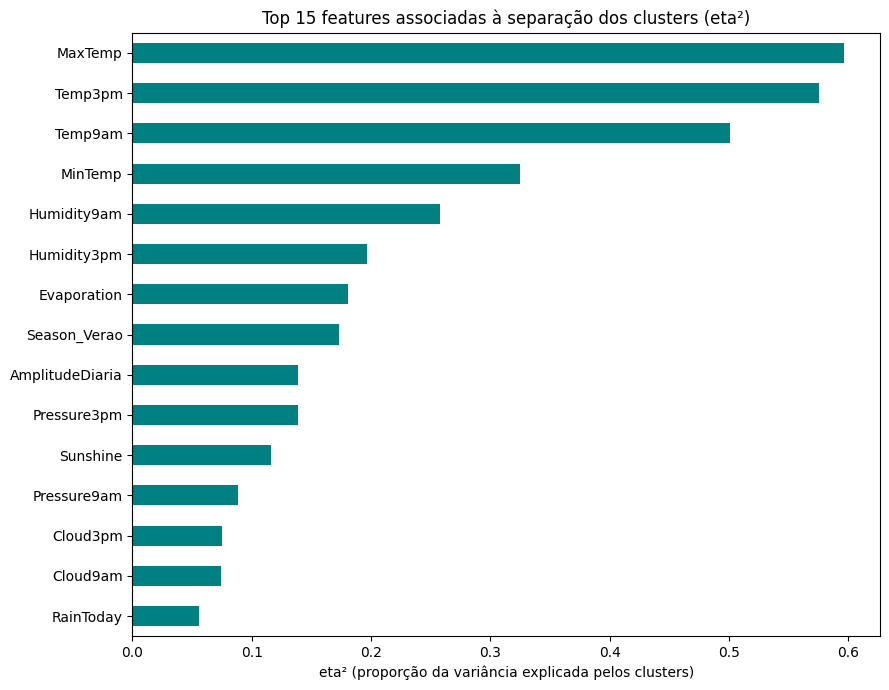

In [ ]:
def eta_squared(values, cluster_labels):
    """
    Proporção da variância total da feature que está entre os clusters.
    Varia de 0 (nenhuma associação) a 1 (separação perfeita).
    """
    values = np.asarray(values)
    grand_mean = values.mean()
    total = ((values - grand_mean) ** 2).sum()
    if total == 0:
        return 0
    between = sum(
        (cluster_labels == c).sum() * (values[cluster_labels == c].mean() - grand_mean) ** 2
        for c in np.unique(cluster_labels)
    )
    return between / total

# Calcula pra todas as features (usando X_train ORIGINAL, não o padronizado — eta² é invariante à escala)
cluster_association = {}
for col in X_train.columns:
    cluster_association[col] = eta_squared(X_train[col].values, clusters)

cluster_feature_importance = (
    pd.Series(cluster_association, name='Associação com cluster (eta²)')
    .sort_values(ascending=False)
)

# Top 15 features que separam os clusters
top_n = 15
print(f"Top {top_n} features que mais separam os clusters:")
print(cluster_feature_importance.head(top_n).to_frame())

# Gráfico
plt.figure(figsize=(9, 7))
cluster_feature_importance.head(top_n).sort_values().plot(kind='barh', color='teal')
plt.title(f'Top {top_n} features associadas à separação dos clusters (eta²)')
plt.xlabel('eta² (proporção da variância explicada pelos clusters)')
plt.tight_layout()
plt.show()

**Step 5** — Side-by-side comparison: clustering vs supervised XGBoost.

In [ ]:
# Importâncias do XGBoost vencedor (que já existe no notebook)
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns,
    name='Importância XGBoost'
).sort_values(ascending=False)

# Tabela lado a lado
comparacao = pd.concat([
    cluster_feature_importance.rename('Clustering (eta²)'),
    xgb_importance.rename('XGBoost (importância)')
], axis=1).fillna(0)

comparacao['Rank clustering'] = comparacao['Clustering (eta²)'].rank(ascending=False, method='min').astype(int)
comparacao['Rank XGBoost']    = comparacao['XGBoost (importância)'].rank(ascending=False, method='min').astype(int)

# Ordena por ranking do clustering
top_n = 15
print(f"Comparação top {top_n} features (ordenado por importância no clustering):\n")
print(comparacao.sort_values('Clustering (eta²)', ascending=False).head(top_n))

# Interseção dos top-N dos dois métodos
top_cluster = set(cluster_feature_importance.head(top_n).index)
top_xgb     = set(xgb_importance.head(top_n).index)
comuns      = top_cluster & top_xgb

print(f"\nFeatures presentes no Top {top_n} dos DOIS métodos ({len(comuns)} de {top_n}):")
for f in sorted(comuns):
    print(f"  - {f}")

print(f"\nFeatures que aparecem SÓ no top do clustering ({len(top_cluster - top_xgb)}):")
for f in sorted(top_cluster - top_xgb):
    print(f"  - {f}")

print(f"\nFeatures que aparecem SÓ no top do XGBoost ({len(top_xgb - top_cluster)}):")
for f in sorted(top_xgb - top_cluster):
    print(f"  - {f}")

Comparação top 15 features (ordenado por importância no clustering):

                 Clustering (eta²)  XGBoost (importância)  Rank clustering  \
MaxTemp                   0.596570               0.006640                1   
Temp3pm                   0.575240               0.006097                2   
Temp9am                   0.500667               0.006327                3   
MinTemp                   0.324730               0.006178                4   
Humidity9am               0.257481               0.006043                5   
Humidity3pm               0.196685               0.090906                6   
Evaporation               0.180751               0.004684                7   
Season_Verao              0.173339               0.013872                8   
AmplitudeDiaria           0.138639               0.005017                9   
Pressure3pm               0.138473               0.018048               10   
Sunshine                  0.115775               0.026956               

**Chart 1** — Horizontal bar chart side by side (top 15 features).

Shows both importances on the same relative scale. Easy to visually see which features are in the top of both methods and which are only in one.

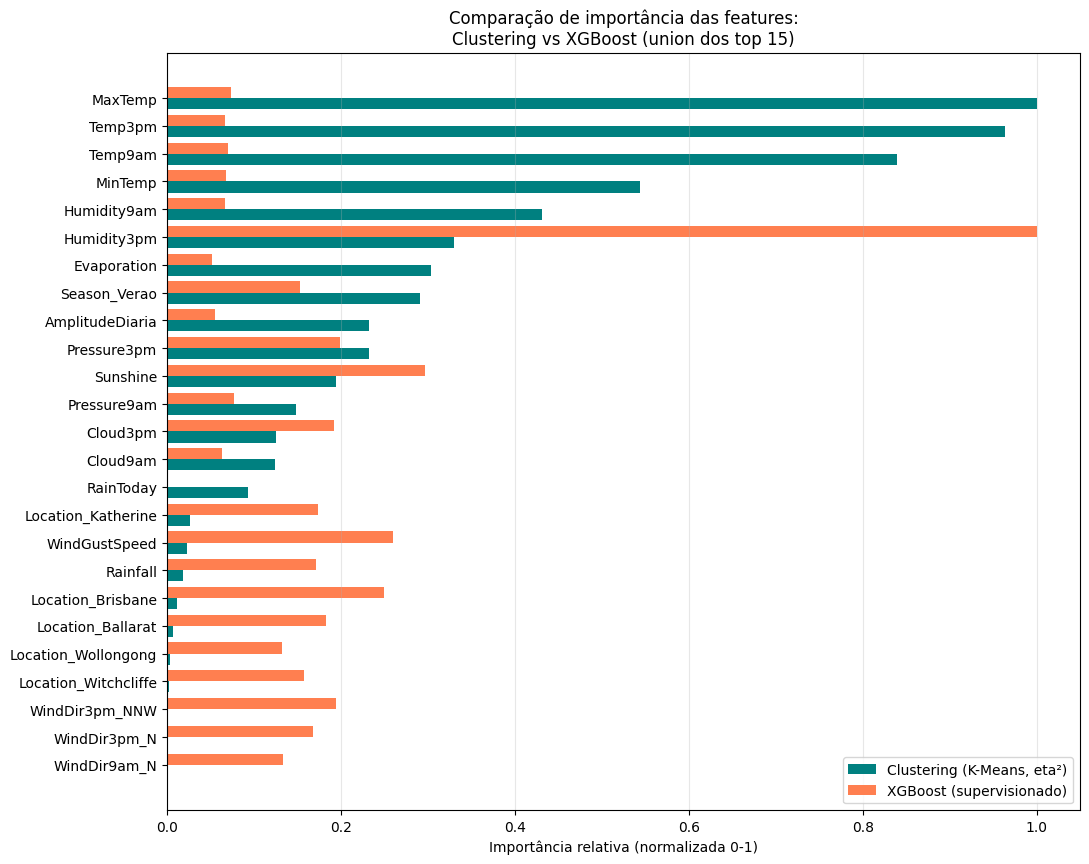

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

top_n = 15

# Normaliza as duas escalas pra 0-1 (senão eta² e importância do XGBoost têm escalas diferentes)
comparacao_norm = comparacao[['Clustering (eta²)', 'XGBoost (importância)']].copy()
comparacao_norm['Clustering (eta²)']    = comparacao_norm['Clustering (eta²)']    / comparacao_norm['Clustering (eta²)'].max()
comparacao_norm['XGBoost (importância)'] = comparacao_norm['XGBoost (importância)'] / comparacao_norm['XGBoost (importância)'].max()

# Pega a união dos top-N dos dois métodos
top_cluster_feats = cluster_feature_importance.head(top_n).index.tolist()
top_xgb_feats     = xgb_importance.head(top_n).index.tolist()
features_plot = list(dict.fromkeys(top_cluster_feats + top_xgb_feats))  # preserva ordem, sem duplicatas

df_plot = comparacao_norm.loc[features_plot].sort_values('Clustering (eta²)', ascending=True)

# Barras horizontais lado a lado
y_pos = np.arange(len(df_plot))
altura = 0.4

fig, ax = plt.subplots(figsize=(11, max(8, len(df_plot)*0.35)))
ax.barh(y_pos - altura/2, df_plot['Clustering (eta²)'],    height=altura, label='Clustering (K-Means, eta²)', color='teal')
ax.barh(y_pos + altura/2, df_plot['XGBoost (importância)'], height=altura, label='XGBoost (supervisionado)',  color='coral')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot.index)
ax.set_xlabel('Importância relativa (normalizada 0-1)')
ax.set_title(f'Comparação de importância das features:\nClustering vs XGBoost (union dos top {top_n})')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


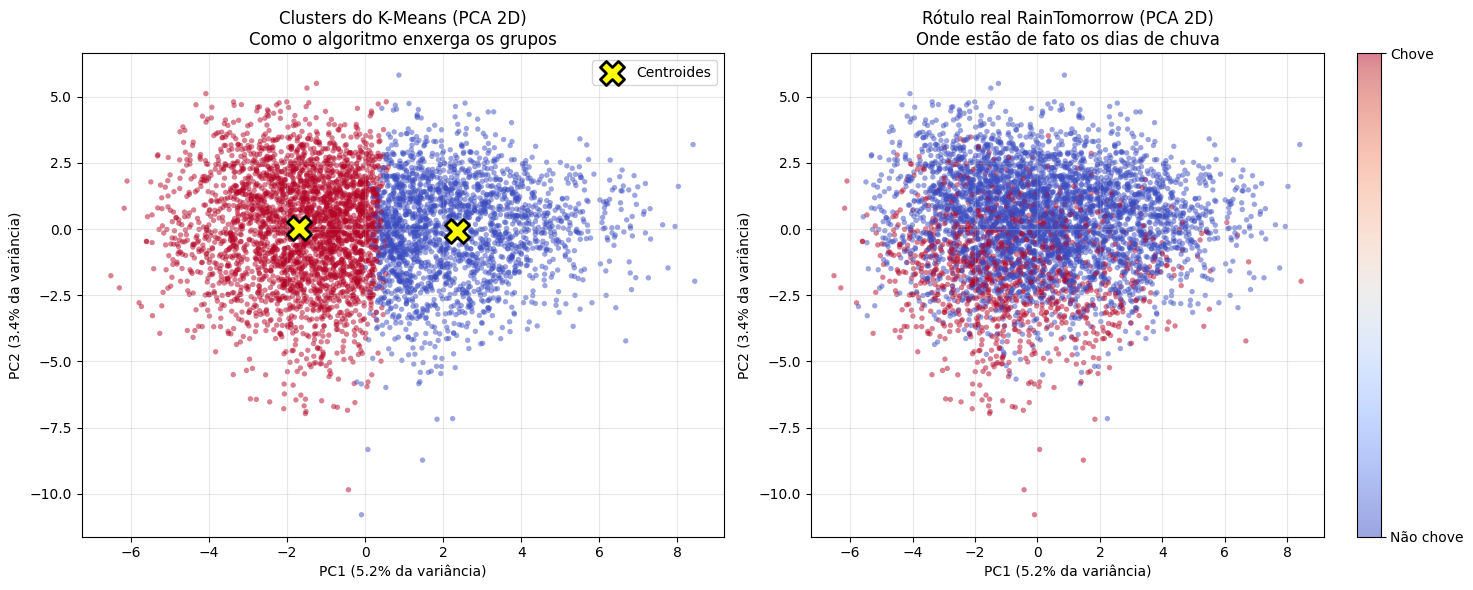


Variância total explicada pelas 2 componentes: 8.6%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduz as ~90 features pra 2 componentes principais
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# Amostra 5000 pontos pra visualização (dataset inteiro fica poluído)
np.random.seed(42)
idx = np.random.choice(len(X_pca), size=5000, replace=False)

# Centroides dos clusters, também projetados no espaço PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Painel esquerdo: colorido pelo cluster do K-Means ---
scatter1 = axes[0].scatter(
    X_pca[idx, 0], X_pca[idx, 1],
    c=clusters[idx], cmap='coolwarm',
    alpha=0.5, s=15, edgecolors='none'
)
axes[0].scatter(
    centroides_pca[:, 0], centroides_pca[:, 1],
    c='yellow', marker='X', s=300, edgecolors='black', linewidth=2,
    label='Centroides', zorder=5
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
axes[0].set_title('Clusters do K-Means (PCA 2D)\nComo o algoritmo enxerga os grupos')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Painel direito: colorido pelo RainTomorrow real ---
scatter2 = axes[1].scatter(
    X_pca[idx, 0], X_pca[idx, 1],
    c=y_train.iloc[idx], cmap='coolwarm',
    alpha=0.5, s=15, edgecolors='none'
)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
axes[1].set_title('Rótulo real RainTomorrow (PCA 2D)\nOnde estão de fato os dias de chuva')
axes[1].grid(alpha=0.3)

# Colorbar do painel direito
cbar = plt.colorbar(scatter2, ax=axes[1], ticks=[0, 1])
cbar.ax.set_yticklabels(['Não chove', 'Chove'])

plt.tight_layout()
plt.show()

print(f"\nVariância total explicada pelas 2 componentes: {sum(pca.explained_variance_ratio_)*100:.1f}%")

**Which features most influence the cluster separation, and how do they compare to the most important features of the supervised model (feature importance, coefficients)? Are they the same?**

**No, they are not the same features — only 5 out of 15 appear in both rankings.**

*   K-Means is dominated by temperature (MaxTemp, Temp3pm, Temp9am, MinTemp in the top 4 positions). This happens because Euclidean distance favors the variables with highest variance, and clustering ends up separating "hot days" from "cold days".
*   XGBoost is dominated by humidity, cloudiness and pressure (Humidity3pm leads by a wide margin, followed by Sunshine, Cloud3pm, Pressure3pm) — the variables that actually precede rain. Temperature barely appears (ranks 62-71 out of ~90 features).


This is the scenario of the second bullet: the problem is not naturally separable by raw distance. The signal relevant for predicting rain is not the dimension that dominates the geometry of the data — which also explains the low silhouette score (0.035) we obtained earlier. This is a legitimate insight: the distance structure is "misleading" here, and reinforces why the supervised model is necessary in this problem.